In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import re
import seaborn as sns
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


BASE_PATH = '/content/drive/MyDrive/Colab_Notebooks/Lab5'
DATA_PATH = '/content/drive/MyDrive/Colab_Notebooks/Lab5/data'
PROCESSED = '/content/drive/MyDrive/Colab_Notebooks/Lab5/processed'

Mounted at /content/drive


### Preprocesamiento

In [3]:
#config
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def emojis(text):
  emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"  #emojis varios
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r'', text)

def preprocesamiento(text):
  if pd.isna(text):
    return ""
  #minusculas
  text = text.lower()
  #eliemiar url
  text = re.sub(r'http\S+|www.\S+|https\S+', '', text)
  #car especiales, puntuacion, etc
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  #espacios mutiples
  text = re.sub(r'\s+', ' ', text).strip()
  #emojis
  text = emojis(text)
  #tok
  tokens = text.split()
  #lemmatizaicon
  tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
  #recontrusccion
  return ' '.join(tokens)

def pre_df(df, text_col='text', keyword_col='keyword'):
    df = df.copy()

    #si keyword, comb con texto
    if keyword_col in df.columns:
        df['full_text'] = df[keyword_col].fillna('') + ' ' + df[text_col]
        df['cleaned_text'] = df['full_text'].apply(preprocesamiento)
    else:
        df['cleaned_text'] = df[text_col].apply(preprocesamiento)

    # Métricas adicionales
    df['word_count'] = df['cleaned_text'].str.split().str.len()
    df['text_length_original'] = df[text_col].str.len()
    df['text_length_cleaned'] = df['cleaned_text'].str.len()

    return df


train_df = pd.read_csv(f'{DATA_PATH}/train.csv')
test_df = pd.read_csv(f'{DATA_PATH}/test.csv')
print("\n--- DATOS CARGADOS ---")
print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

print("\n--- INFO DATASET ---")
print(train_df.info())
print("\n--- FRAGMENTO ---")
print(train_df.head())

print("\n=== PREPROCESAMIENTO DATOS ===")
train_df = pre_df(train_df, text_col='text', keyword_col='keyword')
test_df = pre_df(test_df, text_col='text', keyword_col='keyword')
print(".... Preprocesamiento completado ....")
print(f"Train: {train_df.shape}\nTest: {test_df.shape}")


train_df.to_csv(f'{PROCESSED}/train_preprocessed.csv', index=False)
test_df.to_csv(f'{PROCESSED}/test_preprocessed.csv', index=False)

print(f"Datos preprocesados en {PROCESSED}")


--- DATOS CARGADOS ---
Train: (7613, 5)
Test: (3263, 4)

--- INFO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
None

--- FRAGMENTO ---
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target 

### Analisis exploratorio

=== ANALISIS EXPLORATORIO ===

ESTADISTICAS PREPROCESAMIENTO:
Prom. caracteres originales: 101.16
Prom. caracteres procesados: 71.87
Reduccion promedio: 28.95%
Prom. palabras/tweet: 10.11
Max. palabras en un tweet: 24
Min. palabras en un tweet: 1

--- EJEMPLOS ---

Tweet 1:
Original: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Keyword: nan
Procesado: deed reason earthquake may allah forgive u
++++++++++++++++++++

Tweet 2:
Original: Forest fire near La Ronge Sask. Canada
Keyword: nan
Procesado: forest fire near la ronge sask canada
++++++++++++++++++++

Tweet 3:
Original: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
Keyword: nan
Procesado: resident asked shelter place notified officer evacuation shelter place order expected
++++++++++++++++++++

Tweet 4:
Original: 13,000 people receive #wildfires evacuation orders in California 
Keyword: nan
Procesado: people receive wildf

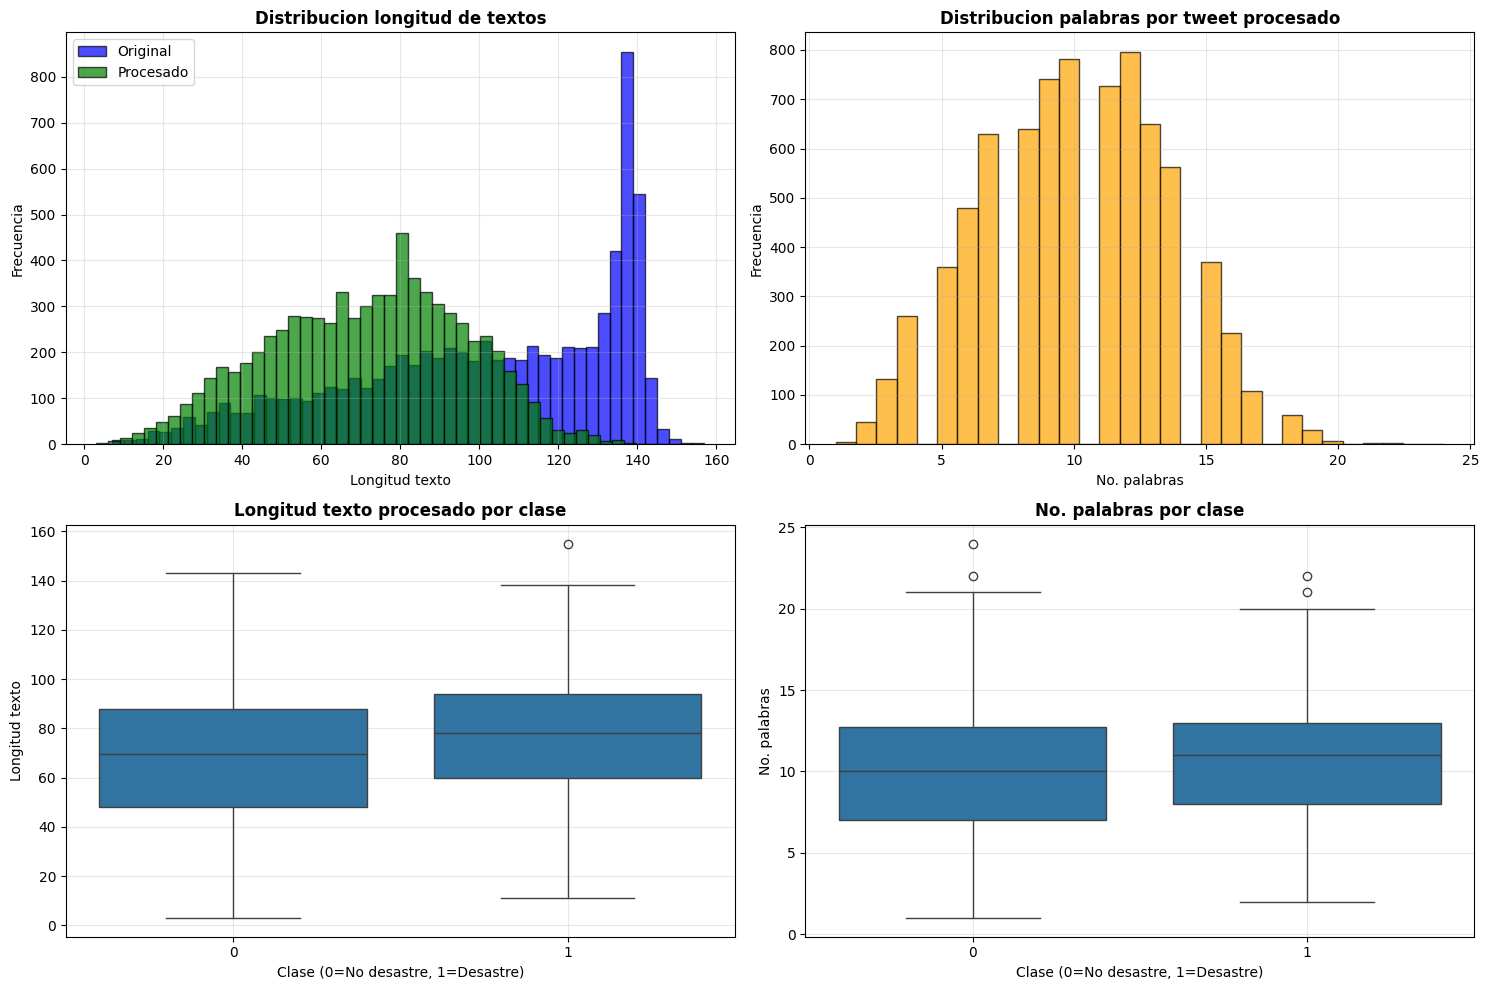

In [4]:
print("=== ANALISIS EXPLORATORIO ===")

print("\nESTADISTICAS PREPROCESAMIENTO:")
print(f"Prom. caracteres originales: {train_df['text_length_original'].mean():.2f}")
print(f"Prom. caracteres procesados: {train_df['text_length_cleaned'].mean():.2f}")
print(f"Reduccion promedio: {((train_df['text_length_original'].mean() - train_df['text_length_cleaned'].mean()) / train_df['text_length_original'].mean() * 100):.2f}%")
print(f"Prom. palabras/tweet: {train_df['word_count'].mean():.2f}")
print(f"Max. palabras en un tweet: {train_df['word_count'].max()}")
print(f"Min. palabras en un tweet: {train_df['word_count'].min()}")

print("\n--- EJEMPLOS ---")
sample_tweets = train_df[['text', 'keyword', 'cleaned_text']].head(5)
for idx, row in sample_tweets.iterrows():
    print(f"\nTweet {idx+1}:")
    print(f"Original: {row['text']}")
    print(f"Keyword: {row['keyword']}")
    print(f"Procesado: {row['cleaned_text']}")
    print("+"*20)

#graficas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#hist. long textos
axes[0, 0].hist(train_df['text_length_original'], bins=50, alpha=0.7, label='Original', color='blue', edgecolor='black')
axes[0, 0].hist(train_df['text_length_cleaned'], bins=50, alpha=0.7, label='Procesado', color='green', edgecolor='black')
axes[0, 0].set_title('Distribucion longitud de textos', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Longitud texto')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

#hist. palabras/tweet
axes[0, 1].hist(train_df['word_count'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribucion palabras por tweet procesado', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('No. palabras')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(True, alpha=0.3)

#long/clase
sns.boxplot(data=train_df, x='target', y='text_length_cleaned', ax=axes[1, 0])
axes[1, 0].set_title('Longitud texto procesado por clase', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Clase (0=No desastre, 1=Desastre)')
axes[1, 0].set_ylabel('Longitud texto')
axes[1, 0].grid(True, alpha=0.3)

#palabras/clase
sns.boxplot(data=train_df, x='target', y='word_count', ax=axes[1, 1])
axes[1, 1].set_title('No. palabras por clase', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Clase (0=No desastre, 1=Desastre)')
axes[1, 1].set_ylabel('No. palabras')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/preprocessing_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


=== ANALISIS FRECUENCIA PALABRAS ===
Top 15 palabras - Desastres:
  fire          (275)
  news          (140)
  wildfire      (136)
  disaster      (133)
  police        (128)
  via           (121)
  flood         (120)
  california    (115)
  suicide       (110)
  storm         (109)
  u             (107)
  amp           (107)
  people        (106)
  bomb          (106)
  family        (105)

Top 15 palabras - No Desastres:
  like          (255)
  im            (248)
  amp           (193)
  get           (185)
  new           (170)
  dont          (154)
  u             (148)
  one           (136)
  body          (117)
  fire          (115)
  time          (105)
  emergency     (105)
  injury        (105)
  video         (102)
  via           (99)


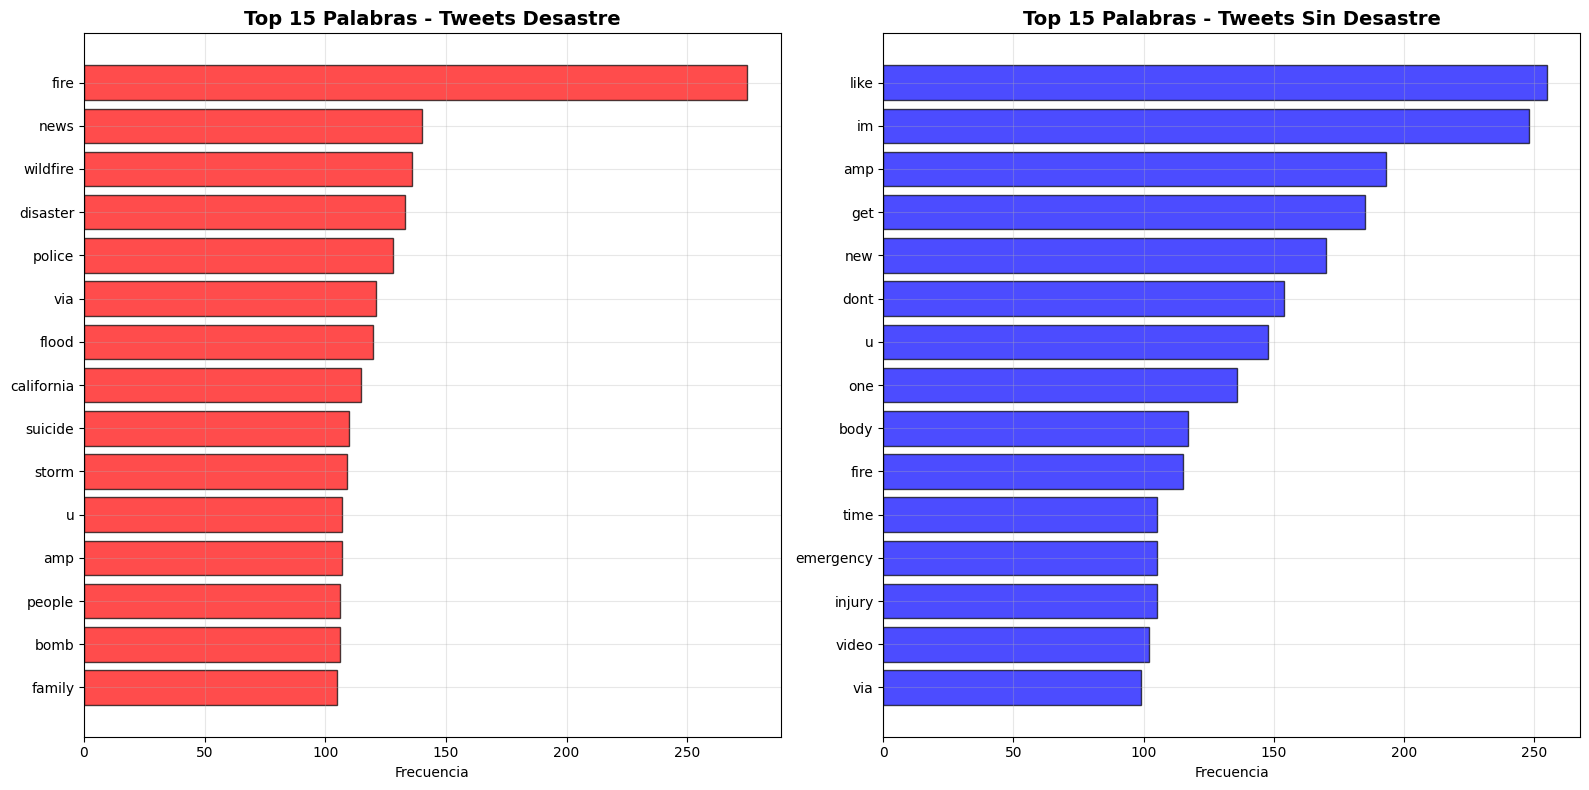

=== PALABRAS DIFERENCIALES POR CLASE ===
Palabras con mayor asociacion a desastres:
  fire            7.4% desastres | 1.9% no desastres (diff: +5.5%)
  california      3.4% desastres | 0.1% no desastres (diff: +3.3%)
  wildfire        3.3% desastres | 0.2% no desastres (diff: +3.1%)
  suicide         3.2% desastres | 0.2% no desastres (diff: +3.0%)
  news            4.1% desastres | 1.3% no desastres (diff: +2.8%)
  killed          2.8% desastres | 0.1% no desastres (diff: +2.7%)
  hiroshima       2.7% desastres | 0.0% no desastres (diff: +2.6%)
  train           2.9% desastres | 0.3% no desastres (diff: +2.6%)
  bombing         2.3% desastres | 0.0% no desastres (diff: +2.2%)
  police          3.0% desastres | 0.8% no desastres (diff: +2.2%)
  disaster        3.0% desastres | 0.9% no desastres (diff: +2.1%)
  mh              2.1% desastres | 0.0% no desastres (diff: +2.1%)
  pm              2.4% desastres | 0.3% no desastres (diff: +2.1%)
  bomb            2.8% desastres | 0.7% no de

In [23]:
print("=== ANALISIS FRECUENCIA PALABRAS ===")

disaster = train_df[train_df['target'] == 1]['cleaned_text']
no_disaster = train_df[train_df['target'] == 0]['cleaned_text']

def palabras_frecuentes(text_series, n=15):
  palabras_total = ' '.join(text_series).split()
  counter = Counter(palabras_total)
  return counter.most_common(n)

top_disaster = palabras_frecuentes(disaster, 15)
top_no_disaster = palabras_frecuentes(no_disaster, 15)

print("Top 15 palabras - Desastres:")
for word, count in top_disaster:
    print(f"  {word:13} ({count})")

print("\nTop 15 palabras - No Desastres:")
for word, count in top_no_disaster:
    print(f"  {word:13} ({count})")

#graficas
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

#desasdtes
words_d, counts_d = zip(*top_disaster)
axes[0].barh(words_d, counts_d, color='red', alpha=0.7, edgecolor='black')
axes[0].set_title('Top 15 Palabras - Tweets Desastre', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frecuencia')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

#no desaastres
words_nd, counts_nd = zip(*top_no_disaster)
axes[1].barh(words_nd, counts_nd, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('Top 15 Palabras - Tweets Sin Desastre', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frecuencia')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/top_words_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


print("=== PALABRAS DIFERENCIALES POR CLASE ===")
def frecuencia(text_series):
  word_count = Counter()
  total_tweets = len(text_series)

  for text in text_series:
    unique_words = set(text.split())
    word_count.update(unique_words)

  return {word: count/total_tweets*100 for word, count in word_count.items()}

disaster_word_freq = frecuencia(disaster)
no_disaster_word_freq = frecuencia(no_disaster)

all_words = set(disaster_word_freq.keys()) | set(no_disaster_word_freq.keys())
word_diff_pct = {}

for word in all_words:
    d_pct = disaster_word_freq.get(word, 0)
    nd_pct = no_disaster_word_freq.get(word, 0)
    word_diff_pct[word] = d_pct - nd_pct

#ordenar
disaster_specific = sorted([(v, k) for k, v in word_diff_pct.items() if v > 0], reverse=True)[:15]
no_disaster_specific = sorted([(v, k) for k, v in word_diff_pct.items() if v < 0])[:15]

print("Palabras con mayor asociacion a desastres:")
for diff, word in disaster_specific:
    d_pct = disaster_word_freq[word]
    nd_pct = no_disaster_word_freq.get(word, 0)
    print(f"  {word:15} {d_pct:.1f}% desastres | {nd_pct:.1f}% no desastres (diff: {diff:+.1f}%)")

print("Palabras con mayor asociacion a no desastres:")
for diff, word in no_disaster_specific:
    d_pct = disaster_word_freq.get(word, 0)
    nd_pct = no_disaster_word_freq[word]
    print(f"  {word:15} {d_pct:.1f}% desastres | {nd_pct:.1f}% no desastres (diff: {diff:+.1f}%)")

=== ANALISIS BIGRAMAS Y TRIGRAMAS ===

--- BIGRAMAS MAS FRECUENTES ---

Desastres:
                   ngram  frecuencia
12        suicide bomber          60
8    northern california          41
9              oil spill          38
2    california wildfire          36
1       burning building          35
13       suicide bombing          34
0       bomber detonated          30
14                yr old          29
10  outbreak legionnaire          29
5             home razed          29
3           confirmed mh          29
6            latest home          28
4         detonated bomb          28
7            mass murder          28
11   severe thunderstorm          28

No Desastres:
                   ngram  frecuencia
0               body bag          48
4             cross body          38
14         youtube video          36
8          liked youtube          35
9              look like          32
7              full read          28
6              feel like          25
1           bo

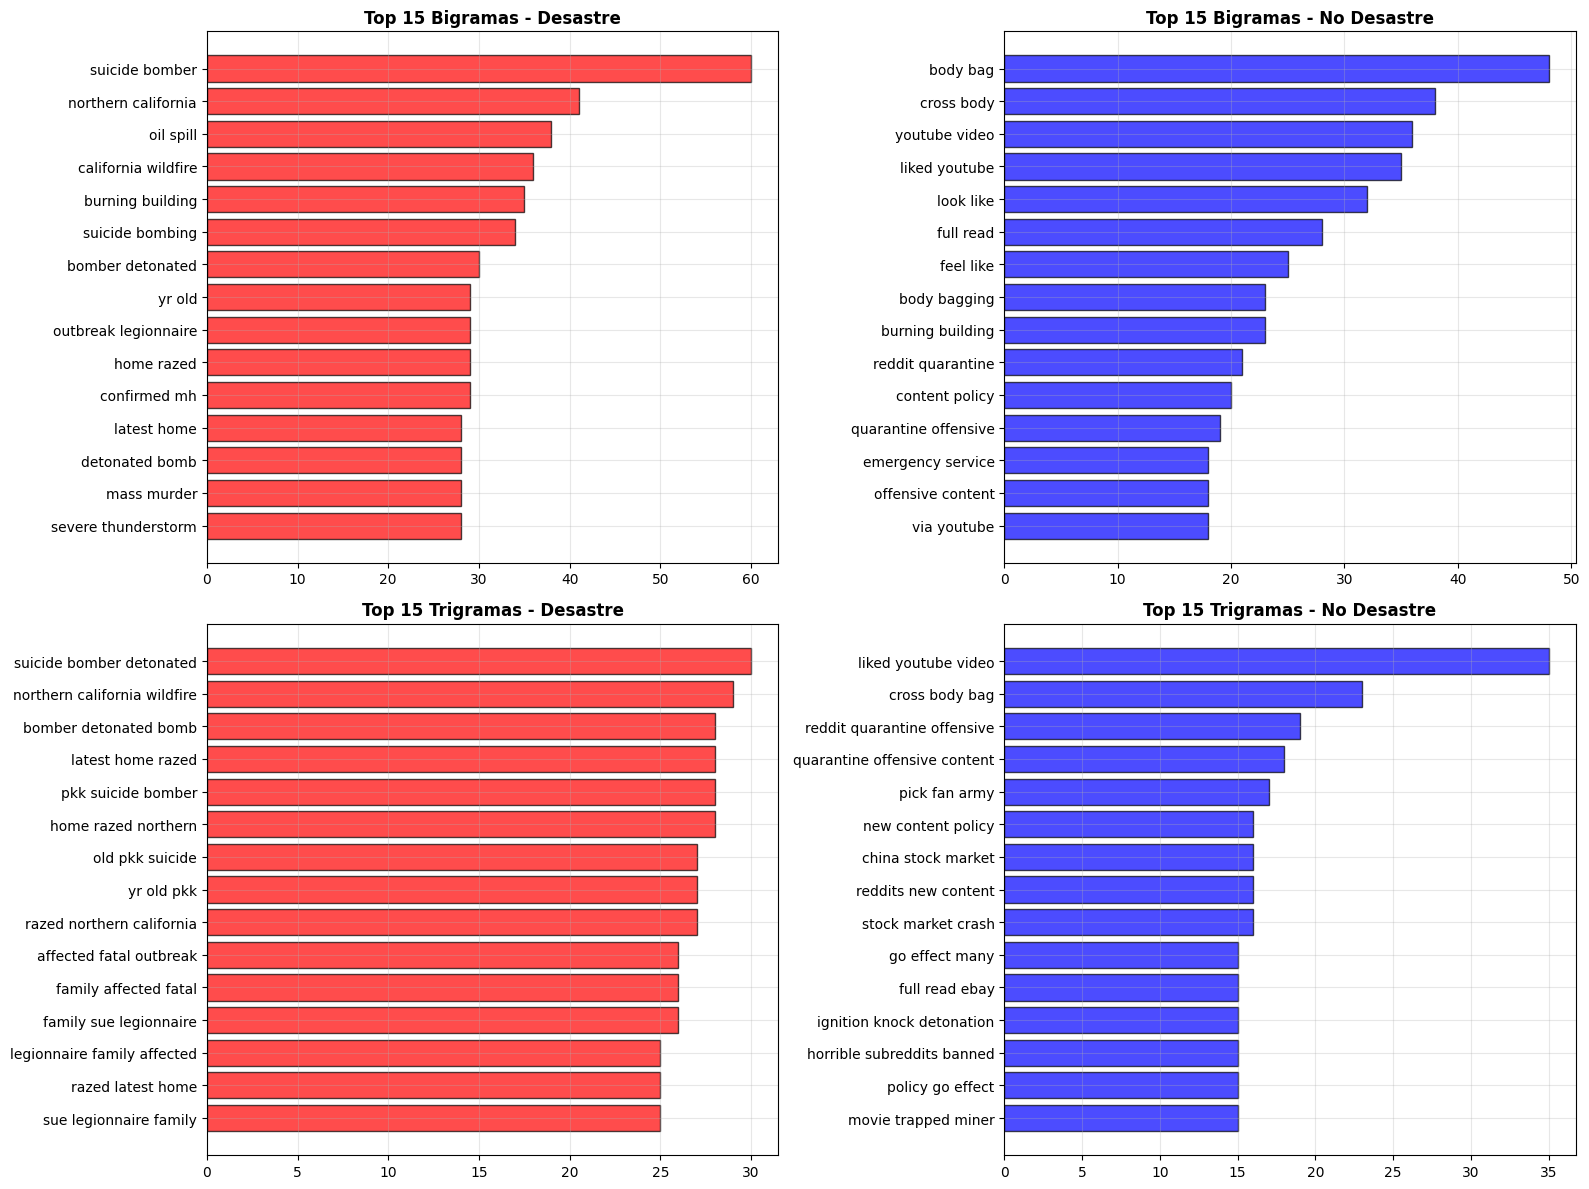

In [25]:
#bigramas y trigramas
print("=== ANALISIS BIGRAMAS Y TRIGRAMAS ===")

def get_ngrams(text_series, ngram_range=(2, 2), top_n=20):
    vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=top_n)
    X = vectorizer.fit_transform(text_series)
    ngram_freq = X.toarray().sum(axis=0)
    ngram_names = vectorizer.get_feature_names_out()

    ngram_df = pd.DataFrame({
        'ngram': ngram_names,
        'frecuencia': ngram_freq
    }).sort_values('frecuencia', ascending=False)

    return ngram_df

#bigramas
print("\n--- BIGRAMAS MAS FRECUENTES ---")
print("\nDesastres:")
bigrams_disaster = get_ngrams(disaster, (2, 2), 15)
print(bigrams_disaster)

print("\nNo Desastres:")
bigrams_non = get_ngrams(no_disaster, (2, 2), 15)
print(bigrams_non)

#trigramas
print("\n--- TRIGRAMAS MAS FRECUENTES ---")
print("\nDesastres:")
trigrams_disaster = get_ngrams(disaster, (3, 3), 15)
print(trigrams_disaster)

print("\nNo Desastres:")
trigrams_non = get_ngrams(no_disaster, (3, 3), 15)
print(trigrams_non)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
#big. dessatre
bigrams_d_plot = bigrams_disaster.head(15)
axes[0, 0].barh(bigrams_d_plot['ngram'], bigrams_d_plot['frecuencia'],
                color='red', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Top 15 Bigramas - Desastre', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3)
#big. no desastre
bigrams_nd_plot = bigrams_non.head(15)
axes[0, 1].barh(bigrams_nd_plot['ngram'], bigrams_nd_plot['frecuencia'],
                color='blue', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Top 15 Bigramas - No Desastre', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(True, alpha=0.3)

#tri. desastre
trigrams_d_plot = trigrams_disaster.head(15)
axes[1, 0].barh(trigrams_d_plot['ngram'], trigrams_d_plot['frecuencia'],
                color='red', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Top 15 Trigramas - Desastre', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3)

#tri. no desastre
trigrams_nd_plot = trigrams_non.head(15)
axes[1, 1].barh(trigrams_nd_plot['ngram'], trigrams_nd_plot['frecuencia'],
                color='blue', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Top 15 Trigramas - No Desastre', fontsize=12, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/ngrams_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Las palabras que hagan referencia directa al incidente, tales como "wildfire" o "flood" son vitales. Sin embargo aludir a elementos un poco más específicos como "fire" o "bomb" podrian ser un poco complicados ya que estas palabras tambien pueden usarse en otros contextos, como por ejemplo expresar que algo estuvo increíble o que algo falló enormemente. <br> Creo que vale la pena mantener en cuenta los hashtags al momento de evaluar las palabras, ya que en redes sociales es bastante común que eventos especificos formen hashtags específicos. Tal como tras el lamentable desastre en Nepal esta semana se formaron hashtags como "#NepalFlood" con el fin de informar sobre el desastre y ayudas a las víctimas.

<br>

Vale la pena explorar bigramas y trigramas ya que pueden darnos **contextos** vitales para la clasificacion del desastre o si tan siquiera lo es. Un ejemplo de los resultados obtenidos podria ser "california wildfire" o "suicide bomber", sin embargo resultados como "nothern carolina" no indican ningún acontecimento de esta índole, ya que solo indican una ubicación y podría ser referente a cualquier suceso en el área. Por otro lado con el trigrama "northen california wildfire" ya sabemos que se trata de un desastre ocurrido en el norte de california.